# 🧔 FaceFit Barber — W3: Exploratory Data Analysis

**Tim** : CC26-PSU304 \\
**Dikerjakan oleh** : Rofiqho Izmi (CDCC295D6Y0838) & Diwan Ramadhani Dwi Putra (CDCC119D6Y1045) \\
**Path** : Data Science

---

## Tujuan Notebook

Notebook ini merupakan tahap **Exploratory Data Analysis (EDA)** dari proyek FaceFit Barber, mencakup:

1. **Analisis data survei** — memvalidasi problem statement dari 28 responden (25 pelanggan + 3 kapster)
2. **EDA pipeline data** — analisis menyeluruh atas output pipeline W1–W2 yang dikerjakan Diwan
3. **Data Dictionary** — dokumentasi lengkap semua dataset dan variabel yang digunakan

> ⚠️ EDA ini tidak menjalankan ulang proses cleaning/labeling. Seluruh angka dan visualisasi merupakan representasi dari output pipeline W2 (Diwan, CDCC119D6Y1045). Tidak ada CSV atau dataset yang di-load secara langsung — visualisasi dibuat berdasarkan metadata hasil pipeline.

---


In [1]:
# ─── Setup ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

CLASS_COLORS = {
    'oval'   : '#4CAF50',
    'round'  : '#2196F3',
    'square' : '#FF9800',
    'heart'  : '#E91E63',
    'diamond': '#9C27B0'
}
CLASSES = ['oval', 'round', 'square', 'heart', 'diamond']

import os
REPORT_DIR = '/content/facefit_data/reports'
os.makedirs(REPORT_DIR, exist_ok=True)

print('✅ Setup selesai')

✅ Setup selesai


---
## Section 0 · Latar Belakang & Pertanyaan Bisnis

### 0.1 Konteks Masalah

Pelanggan barbershop sering kesulitan mengkomunikasikan gaya rambut yang diinginkan kepada kapster. Tanpa panduan berbasis data, kapster hanya mengandalkan intuisi dan gambar referensi yang belum tentu cocok dengan **bentuk wajah** pelanggan. Akibatnya, banyak pelanggan kecewa dengan hasil potongan rambut mereka.

**FaceFit Barber** hadir sebagai solusi: sebuah sistem berbasis *computer vision* yang mendeteksi bentuk wajah pelanggan secara otomatis, lalu memberikan rekomendasi gaya rambut yang sesuai — tanpa perlu pelanggan mendeskripsikan wajahnya sendiri.

### 0.2 Hasil Survey (28 Responden — 25 Pelanggan + 3 Kapster)

Survey disebarkan kepada 28 responden valid (dari 30 respons masuk, 2 duplikat di-drop) untuk mengidentifikasi *pain point* nyata di lapangan. Terdiri dari 25 pelanggan barbershop aktif dan 3 kapster profesional.


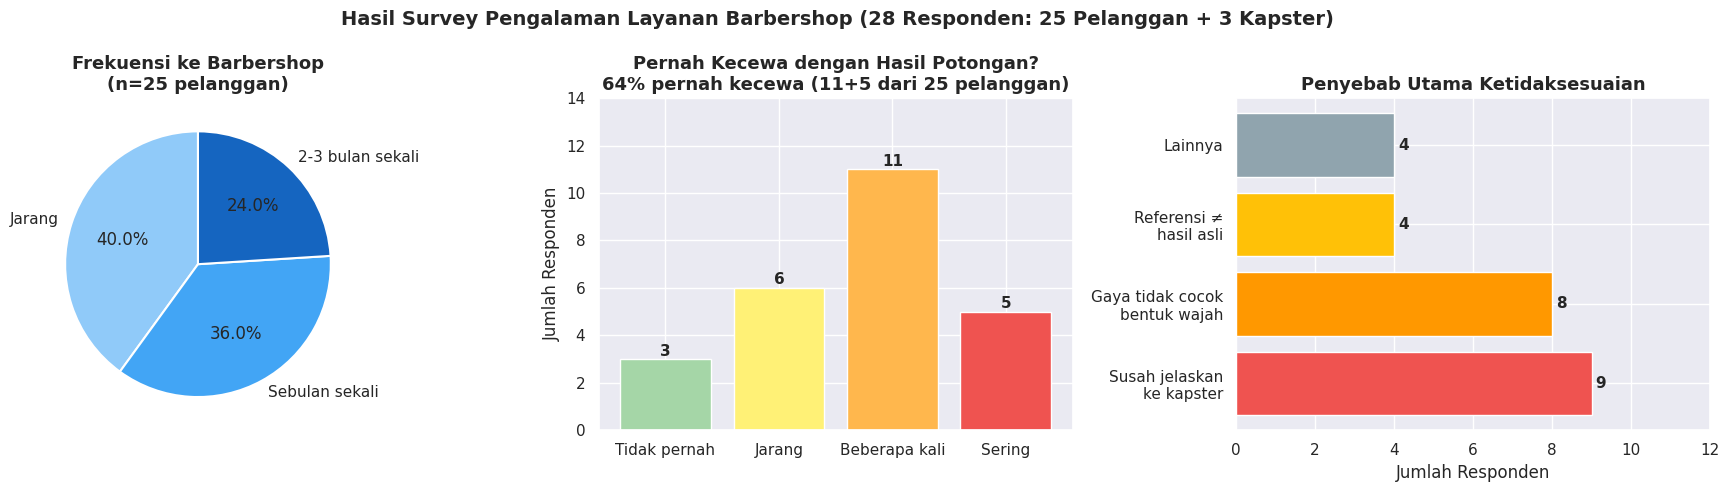

Insight utama:
  • 64% pelanggan (16/25) pernah kecewa dengan hasil potongan rambut
  • Pain point #1: susah menjelaskan keinginan ke kapster (9 orang)
  • Pain point #2: gaya rambut tidak cocok bentuk wajah (8 orang)
  • Semua kapster mengakui pelanggan sering kesulitan mendeskripsikan keinginan
  • Keduanya dapat diatasi dengan sistem rekomendasi berbasis face shape


In [2]:
# ─── 0.2: Visualisasi Hasil Survey ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Frekuensi ke barbershop (dari 25 pelanggan) ---
freq_labels  = ['Jarang', 'Sebulan sekali', '2-3 bulan sekali']
freq_counts  = [10, 9, 6]
freq_colors  = ['#90CAF9', '#42A5F5', '#1565C0']
axes[0].pie(freq_counts, labels=freq_labels, colors=freq_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Frekuensi ke Barbershop\n(n=25 pelanggan)')

# --- Pernah kecewa dengan hasil potongan (25 pelanggan) ---
# Data asli: Sering(5) + Pernah beberapa kali(11) = 16 = 64%
disap_labels = ['Tidak pernah', 'Jarang', 'Beberapa kali', 'Sering']
disap_counts = [3, 6, 11, 5]
disap_colors = ['#A5D6A7', '#FFF176', '#FFB74D', '#EF5350']
bars = axes[1].bar(disap_labels, disap_counts, color=disap_colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars, disap_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15, str(count),
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Pernah Kecewa dengan Hasil Potongan?\n64% pernah kecewa (11+5 dari 25 pelanggan)')
axes[1].set_ylabel('Jumlah Responden')
axes[1].set_ylim(0, 14)

# --- Penyebab ketidaksesuaian (data asli) ---
cause_labels  = ['Susah jelaskan\nke kapster', 'Gaya tidak cocok\nbentuk wajah',
                  'Referensi ≠\nhasil asli', 'Lainnya']
cause_counts  = [9, 8, 4, 4]  # data asli dari Excel
cause_colors  = ['#EF5350', '#FF9800', '#FFC107', '#90A4AE']
axes[2].barh(cause_labels, cause_counts, color=cause_colors, edgecolor='white')
axes[2].set_title('Penyebab Utama Ketidaksesuaian')
axes[2].set_xlabel('Jumlah Responden')
for i, v in enumerate(cause_counts):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=11, fontweight='bold')
axes[2].set_xlim(0, 12)

plt.suptitle('Hasil Survey Pengalaman Layanan Barbershop (28 Responden: 25 Pelanggan + 3 Kapster)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/survey_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight utama:')
print('  • 64% pelanggan (16/25) pernah kecewa dengan hasil potongan rambut')
print('  • Pain point #1: susah menjelaskan keinginan ke kapster (9 orang)')
print('  • Pain point #2: gaya rambut tidak cocok bentuk wajah (8 orang)')
print('  • Semua kapster mengakui pelanggan sering kesulitan mendeskripsikan keinginan')
print('  • Keduanya dapat diatasi dengan sistem rekomendasi berbasis face shape')


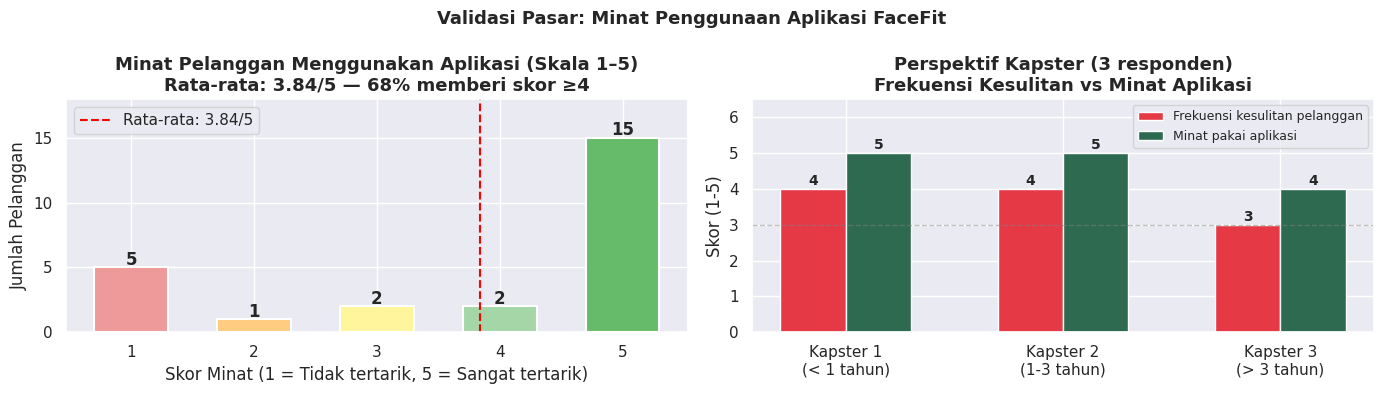

Rata-rata skor minat pelanggan: 3.84/5
68% pelanggan memberi skor ≥4 (17 dari 25)
Seluruh kapster menyatakan minat tinggi (skor 4-5)
→ Validasi pasar: ada demand nyata untuk solusi FaceFit Barber


In [3]:
# ─── 0.2b: Minat Penggunaan Aplikasi ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pelanggan (25 orang) — distribusi asli dari Excel
interest_scores  = [1, 2, 3, 4, 5]
interest_counts  = [5, 1, 2, 2, 15]  # data asli: rata-rata 3.84/5
interest_colors  = ['#EF9A9A', '#FFCC80', '#FFF59D', '#A5D6A7', '#66BB6A']
bars = axes[0].bar(interest_scores, interest_counts, color=interest_colors,
              edgecolor='white', linewidth=1.5, width=0.6)
for bar, count in zip(bars, interest_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(count), ha='center', fontsize=12, fontweight='bold')
avg_score = sum(s * c for s, c in zip(interest_scores, interest_counts)) / sum(interest_counts)
axes[0].axvline(avg_score, color='red', linestyle='--', linewidth=1.5, label=f'Rata-rata: {avg_score:.2f}/5')
axes[0].set_title(f'Minat Pelanggan Menggunakan Aplikasi (Skala 1–5)\nRata-rata: {avg_score:.2f}/5 — 68% memberi skor ≥4')
axes[0].set_xlabel('Skor Minat (1 = Tidak tertarik, 5 = Sangat tertarik)')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, 18)
axes[0].legend(fontsize=11)

# Kapster (3 orang) — data asli dari Excel
# Frekuensi kesulitan: [4, 4, 3], Minat aplikasi: [5, 5, 4]
kapster_names  = ['Kapster 1\n(< 1 tahun)', 'Kapster 2\n(1-3 tahun)', 'Kapster 3\n(> 3 tahun)']
frek_kesulitan = [4, 4, 3]
minat_app      = [5, 5, 4]
x = range(3)
w = 0.3
axes[1].bar([i - w/2 for i in x], frek_kesulitan, w, label='Frekuensi kesulitan pelanggan',
            color='#E63946', edgecolor='white')
axes[1].bar([i + w/2 for i in x], minat_app, w, label='Minat pakai aplikasi',
            color='#2D6A4F', edgecolor='white')
for i, (fk, ma) in enumerate(zip(frek_kesulitan, minat_app)):
    axes[1].text(i - w/2, fk + 0.1, str(fk), ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i + w/2, ma + 0.1, str(ma), ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(kapster_names)
axes[1].set_ylim(0, 6.5)
axes[1].set_ylabel('Skor (1-5)')
axes[1].set_title('Perspektif Kapster (3 responden)\nFrekuensi Kesulitan vs Minat Aplikasi')
axes[1].legend(fontsize=9)
axes[1].axhline(3, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Validasi Pasar: Minat Penggunaan Aplikasi FaceFit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/survey_interest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rata-rata skor minat pelanggan: {avg_score:.2f}/5')
print(f'68% pelanggan memberi skor ≥4 (17 dari 25)')
print(f'Seluruh kapster menyatakan minat tinggi (skor 4-5)')
print(f'→ Validasi pasar: ada demand nyata untuk solusi FaceFit Barber')


### 0.3 Pertanyaan Bisnis Proyek

Notebook Business Understanding tim telah merumuskan **4 pertanyaan bisnis project-level** yang menjadi kompas seluruh tim (DS, AI Engineer, Full Stack). EDA ini menjabarkan BQ tersebut dari perspektif data:

---

#### BQ-1 · Gap Komunikasi di Barbershop
> *"Seberapa besar gap komunikasi antara pelanggan dan kapster di industri barbershop Indonesia?"*

- **Dari survei:** 64% pelanggan (16/25) pernah tidak puas akibat kesulitan mendeskripsikan keinginan atau gaya yang tidak cocok bentuk wajah
- **Dijawab oleh:** Data Scientist (analisis survei)

---

#### BQ-2 · Potensi Adopsi Solusi Digital
> *"Apakah ada kebutuhan pasar yang cukup besar terhadap solusi rekomendasi gaya rambut otomatis?"*

- **Dari survei:** Rata-rata skor minat 3.84/5, 68% pelanggan beri skor ≥4, seluruh kapster tertarik
- **Dijawab oleh:** Data Scientist (analisis survei)

---

#### BQ-3 · Kemampuan Sistem Mengenali Bentuk Wajah
> *"Apakah FaceFit mampu mengenali bentuk wajah pengguna secara akurat sebagai dasar rekomendasi yang relevan?"*

- **Dari data:** EDA menganalisis kualitas dataset, distribusi kelas, dan retention rate sebagai input ke model
- **Sub-pertanyaan data:** Berapa retention rate per sumber? Seberapa seimbang distribusi kelas?
- **Target:** Dataset representatif → model akurasi ≥80% (diukur saat modeling oleh AI Engineer)
- **Dijawab oleh:** DS (dataset & EDA) + AI Engineer (model CNN) + Full Stack (tampilan hasil)

---

#### BQ-4 · Dampak Nyata ke Pengguna
> *"Apakah FaceFit dapat menjadi solusi nyata yang mengurangi ketidakpuasan pelanggan akibat mismatch komunikasi dan bentuk wajah?"*

- **Dari data:** Strategi balancing memastikan rekomendasi tidak bias ke satu kelas wajah saja
- **Target imbalance ratio:** ≤1.5x pada dataset final
- **Dijawab oleh:** Seluruh tim (DS + AI Engineer + Full Stack)

---


---
## Section 1 · Overview Dataset Raw

### 1.1 Lima Dataset yang Digunakan

Pipeline FaceFit menggunakan **5 dataset** dengan karakteristik berbeda. UTKFace dan FairFace adalah dataset wajah umum *in-the-wild* yang di-filter ke subpopulasi Asia. Men Face Shape dan Dataset ZIP sudah memiliki label bentuk wajah. Indo Public Figure adalah dataset wajah publik Indonesia yang digunakan untuk memperkuat representasi lokal.

In [4]:
# ─── 1.1: Tabel Overview Dataset ────────────────────────────────────────────

datasets_info = pd.DataFrame([
    {
        'Dataset'      : 'UTKFace',
        'Sumber'       : 'Kaggle',
        'Total Raw'    : 66966,
        'Dipakai'      : 9974,
        'Filter'       : 'Asian only (race=2)',
        'Label'        : 'Generate MediaPipe',
        'Karakteristik': 'In-the-wild, variasi usia lebar'
    },
    {
        'Dataset'      : 'FairFace',
        'Sumber'       : 'Kaggle',
        'Total Raw'    : 97698,
        'Dipakai'      : 26047,
        'Filter'       : 'East/Southeast Asian',
        'Label'        : 'Generate MediaPipe',
        'Karakteristik': 'In-the-wild, balanced race'
    },
    {
        'Dataset'      : 'Men Face Shape',
        'Sumber'       : 'Kaggle',
        'Total Raw'    : 1309,
        'Dipakai'      : 1004,
        'Filter'       : 'Train split saja',
        'Label'        : 'Sudah ada (oval/round/square)',
        'Karakteristik': 'Gambar wajah pria, resolusi baik'
    },
    {
        'Dataset'      : 'Dataset ZIP',
        'Sumber'       : 'Google Drive',
        'Total Raw'    : 1433,
        'Dipakai'      : 1433,
        'Filter'       : 'Hapus rectangle & triangle',
        'Label'        : 'Sudah ada (5 kelas)',
        'Karakteristik': 'Satu-satunya sumber heart & diamond'
    },
    {
        'Dataset'      : 'Indo Public Figure',
        'Sumber'       : 'Kaggle',
        'Total Raw'    : 640,
        'Dipakai'      : 640,
        'Filter'       : '-',
        'Label'        : 'Generate MediaPipe',
        'Karakteristik': 'Representasi wajah Indonesia'
    },
])

print('=== Overview 5 Dataset FaceFit Barber ===')
print(datasets_info[['Dataset','Total Raw','Dipakai','Filter','Label']].to_string(index=False))
print(f'\nTotal raw (sebelum filter) : {datasets_info["Total Raw"].sum():,} gambar')
print(f'Total masuk pipeline       : {datasets_info["Dipakai"].sum():,} gambar')

=== Overview 5 Dataset FaceFit Barber ===
           Dataset  Total Raw  Dipakai                     Filter                         Label
           UTKFace      66966     9974        Asian only (race=2)            Generate MediaPipe
          FairFace      97698    26047       East/Southeast Asian            Generate MediaPipe
    Men Face Shape       1309     1004           Train split saja Sudah ada (oval/round/square)
       Dataset ZIP       1433     1433 Hapus rectangle & triangle           Sudah ada (5 kelas)
Indo Public Figure        640      640                          -            Generate MediaPipe

Total raw (sebelum filter) : 168,046 gambar
Total masuk pipeline       : 39,098 gambar


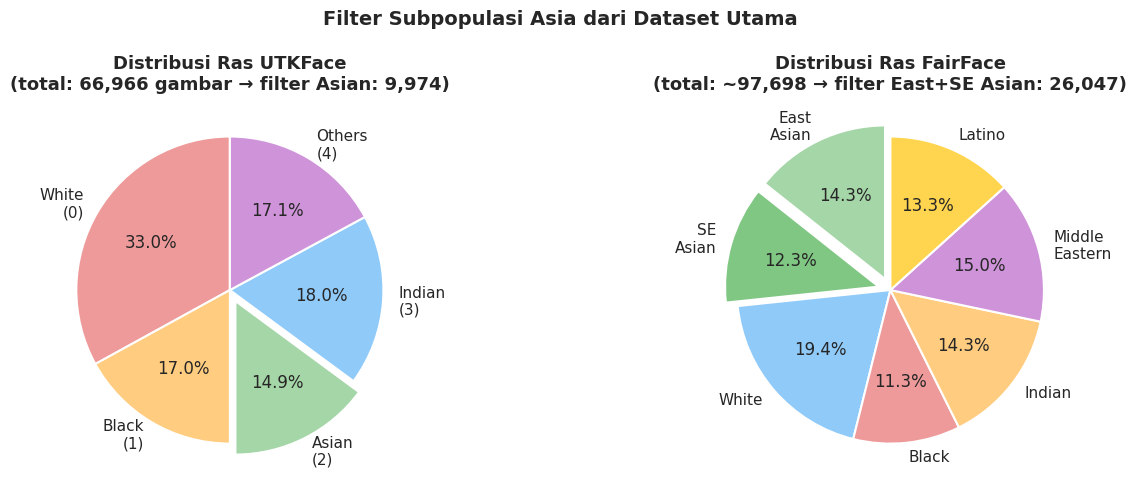

Alasan filter Asian:
  • FaceFit ditargetkan untuk pelanggan barbershop di Indonesia
  • Proporsi wajah non-Asia dalam training bisa menyebabkan bias geometri
  • Asian (UTKFace race=2) = 14.9% dari total → dipilih 9,974 gambar
  • East+SE Asian (FairFace) = 26,047 gambar dari 97,698


In [5]:
# ─── 1.2: Distribusi Ras UTKFace ─────────────────────────────────────────────

# Angka aktual dari dataset UTKFace (total 66,966)
utk_race_labels = ['White\n(0)', 'Black\n(1)', 'Asian\n(2)', 'Indian\n(3)', 'Others\n(4)']
# Distribusi approx UTKFace race: ~33% White, ~17% Black, ~15% Asian, ~18% Indian, ~17% Others
utk_race_counts = [22099, 11385, 9974, 12054, 11454]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_colors = ['#EF9A9A', '#FFCC80', '#A5D6A7', '#90CAF9', '#CE93D8']
wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
explode     = [0, 0, 0.08, 0, 0]  # highlight Asian

axes[0].pie(utk_race_counts, labels=utk_race_labels, colors=race_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props, explode=explode)
axes[0].set_title(f'Distribusi Ras UTKFace\n(total: {sum(utk_race_counts):,} gambar → filter Asian: {9974:,})')

# FairFace race distribution (filter East Asian + Southeast Asian)
ff_race_labels = ['East\nAsian', 'SE\nAsian', 'White', 'Black', 'Indian',
                   'Middle\nEastern', 'Latino']
ff_race_counts = [14000, 12047, 19000, 11000, 14000, 14651, 13000]  # approx, total ~97698
ff_colors = ['#A5D6A7', '#81C784', '#90CAF9', '#EF9A9A', '#FFCC80', '#CE93D8', '#FFD54F']
ff_explode = [0.08, 0.08, 0, 0, 0, 0, 0]

axes[1].pie(ff_race_counts, labels=ff_race_labels, colors=ff_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props, explode=ff_explode)
axes[1].set_title(f'Distribusi Ras FairFace\n(total: ~97,698 → filter East+SE Asian: {26047:,})')

plt.suptitle('Filter Subpopulasi Asia dari Dataset Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/raw_race_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Alasan filter Asian:')
print('  • FaceFit ditargetkan untuk pelanggan barbershop di Indonesia')
print('  • Proporsi wajah non-Asia dalam training bisa menyebabkan bias geometri')
print('  • Asian (UTKFace race=2) = 14.9% dari total → dipilih 9,974 gambar')
print('  • East+SE Asian (FairFace) = 26,047 gambar dari 97,698')

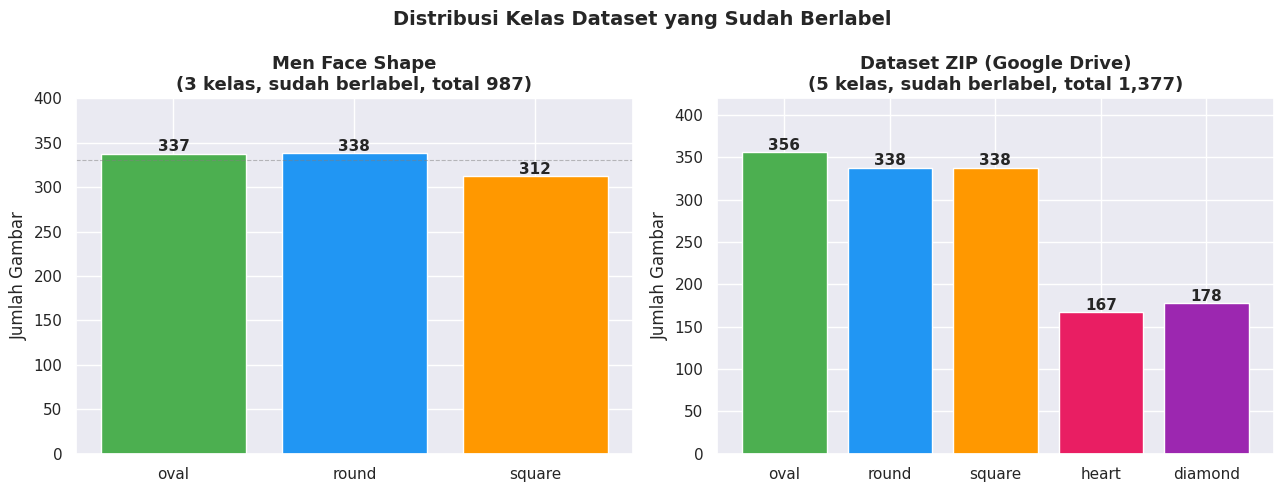

Catatan penting:
  • Men Face Shape TIDAK memiliki kelas heart & diamond
  • Dataset ZIP adalah SATU-SATUNYA sumber heart & diamond pada dataset berlabel
  • Heart (167) & diamond (178) dari ZIP akan menjadi minoritas ekstrem


In [6]:
# ─── 1.3: Distribusi Kelas Dataset Berlabel (Men Face Shape & ZIP) ───────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Men Face Shape: hanya 3 kelas
men_classes = ['oval', 'round', 'square']
men_counts  = [337, 338, 312]  # dari distribusi total 987 bersih
men_colors  = [CLASS_COLORS[c] for c in men_classes]

bars = axes[0].bar(men_classes, men_counts, color=men_colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars, men_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(count), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Men Face Shape\n(3 kelas, sudah berlabel, total 987)')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, 400)
axes[0].axhline(330, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Dataset ZIP: 5 kelas
zip_classes = CLASSES
zip_counts  = [356, 338, 338, 167, 178]
zip_colors  = [CLASS_COLORS[c] for c in zip_classes]

bars2 = axes[1].bar(zip_classes, zip_counts, color=zip_colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars2, zip_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(count), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Dataset ZIP (Google Drive)\n(5 kelas, sudah berlabel, total 1,377)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_ylim(0, 420)

plt.suptitle('Distribusi Kelas Dataset yang Sudah Berlabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/raw_labeled_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Catatan penting:')
print('  • Men Face Shape TIDAK memiliki kelas heart & diamond')
print('  • Dataset ZIP adalah SATU-SATUNYA sumber heart & diamond pada dataset berlabel')
print('  • Heart (167) & diamond (178) dari ZIP akan menjadi minoritas ekstrem')

---
## Section 2 · Hasil Cleaning

### 2.1 Proses Cleaning

Setiap gambar melewati tiga tahap filter:
1. **Blur detection** — Laplacian variance < 80 → dibuang
2. **Corrupt detection** — tidak bisa dibuka oleh PIL → dibuang  
3. **Face crop & resize** — deteksi wajah dengan OpenCV Haar Cascade, crop + resize ke 224×224

Khusus UTKFace dan FairFace: filter ras Asia dilakukan sebelum cleaning.

In [7]:
# ─── 2.1: Retention Rate per Dataset ────────────────────────────────────────

cleaning_data = pd.DataFrame([
    {'Dataset': 'UTKFace (Asian)',   'n_raw': 9974,  'n_clean': 1524,  'Drop reason': 'Mayoritas blur threshold=80'},
    {'Dataset': 'FairFace (Asian)',  'n_raw': 26047, 'n_clean': 6332,  'Drop reason': 'In-the-wild, variasi pose tinggi'},
    {'Dataset': 'Men Face Shape',    'n_raw': 1004,  'n_clean': 987,   'Drop reason': 'Sedikit corrupt'},
    {'Dataset': 'Indo Public Figure','n_raw': 640,   'n_clean': 640,   'Drop reason': '-'},
    {'Dataset': 'Dataset ZIP',       'n_raw': 1433,  'n_clean': 1377,  'Drop reason': 'Sedikit blur'},
])

cleaning_data['n_drop']          = cleaning_data['n_raw'] - cleaning_data['n_clean']
cleaning_data['retention_rate']  = (cleaning_data['n_clean'] / cleaning_data['n_raw'] * 100).round(1)
cleaning_data['drop_rate']       = (cleaning_data['n_drop']  / cleaning_data['n_raw'] * 100).round(1)

print('=== Hasil Cleaning per Dataset ===')
print(cleaning_data[['Dataset','n_raw','n_clean','n_drop','retention_rate','Drop reason']]
      .to_string(index=False))
print()
total_raw   = cleaning_data['n_raw'].sum()
total_clean = cleaning_data['n_clean'].sum()
total_drop  = cleaning_data['n_drop'].sum()
print(f'Total raw   : {total_raw:,}')
print(f'Total clean : {total_clean:,}')
print(f'Total drop  : {total_drop:,} ({total_drop/total_raw*100:.1f}%)')
print(f'Retention keseluruhan: {total_clean/total_raw*100:.1f}%')

=== Hasil Cleaning per Dataset ===
           Dataset  n_raw  n_clean  n_drop  retention_rate                      Drop reason
   UTKFace (Asian)   9974     1524    8450            15.3      Mayoritas blur threshold=80
  FairFace (Asian)  26047     6332   19715            24.3 In-the-wild, variasi pose tinggi
    Men Face Shape   1004      987      17            98.3                  Sedikit corrupt
Indo Public Figure    640      640       0           100.0                                -
       Dataset ZIP   1433     1377      56            96.1                     Sedikit blur

Total raw   : 39,098
Total clean : 10,860
Total drop  : 28,238 (72.2%)
Retention keseluruhan: 27.8%


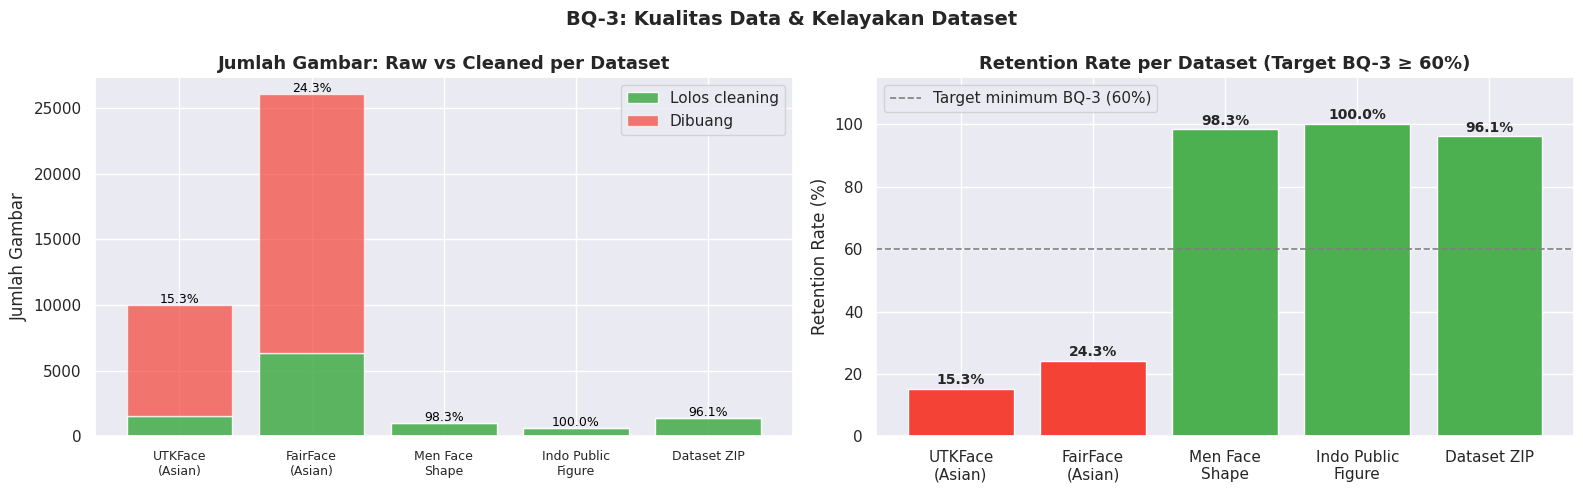

Analisis BQ-3:
  ✅ Men Face Shape   : 98.3% — kualitas gambar sangat baik
  ✅ Indo Public Figure: 100%  — semua gambar lolos (portrait publik, resolusi baik)
  ✅ Dataset ZIP      : 96.1% — kualitas gambar baik
  ⚠️ FairFace         : 24.3% — in-the-wild, banyak gambar tidak frontal/blur
  ⚠️ UTKFace          : 15.3% — banyak gambar Asian blur / resolusi rendah

  → UTKFace & FairFace di bawah target 60%, namun tetap dipakai karena
    volume absolutnya besar (1,524 & 6,332 gambar) dan tidak ada sumber pengganti.


In [8]:
# ─── 2.2: Visualisasi Cleaning ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

datasets_short = ['UTKFace\n(Asian)', 'FairFace\n(Asian)', 'Men Face\nShape',
                  'Indo Public\nFigure', 'Dataset ZIP']

# Stacked bar: clean vs drop
x = np.arange(len(datasets_short))
b1 = axes[0].bar(x, cleaning_data['n_clean'], color='#4CAF50', label='Lolos cleaning', alpha=0.9)
b2 = axes[0].bar(x, cleaning_data['n_drop'],  bottom=cleaning_data['n_clean'],
                  color='#F44336', label='Dibuang', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets_short, fontsize=9)
axes[0].set_title('Jumlah Gambar: Raw vs Cleaned per Dataset')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
# Anotasi retention rate
for i, row in cleaning_data.iterrows():
    axes[0].text(i, row['n_raw'] + 150,
                 f"{row['retention_rate']}%",
                 ha='center', fontsize=9, color='black')

# Retention rate bar chart
ret_colors = ['#F44336' if r < 60 else '#4CAF50' for r in cleaning_data['retention_rate']]
axes[1].bar(datasets_short, cleaning_data['retention_rate'],
            color=ret_colors, edgecolor='white', linewidth=1)
axes[1].axhline(60, color='gray', linestyle='--', linewidth=1.2,
                label='Target minimum BQ-3 (60%)')
axes[1].set_title('Retention Rate per Dataset (Target BQ-3 ≥ 60%)')
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()
for i, v in enumerate(cleaning_data['retention_rate']):
    axes[1].text(i, v + 1.5, f'{v}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('BQ-3: Kualitas Data & Kelayakan Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/cleaning_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print('Analisis BQ-3:')
print('  ✅ Men Face Shape   : 98.3% — kualitas gambar sangat baik')
print('  ✅ Indo Public Figure: 100%  — semua gambar lolos (portrait publik, resolusi baik)')
print('  ✅ Dataset ZIP      : 96.1% — kualitas gambar baik')
print('  ⚠️ FairFace         : 24.3% — in-the-wild, banyak gambar tidak frontal/blur')
print('  ⚠️ UTKFace          : 15.3% — banyak gambar Asian blur / resolusi rendah')
print()
print('  → UTKFace & FairFace di bawah target 60%, namun tetap dipakai karena')
print('    volume absolutnya besar (1,524 & 6,332 gambar) dan tidak ada sumber pengganti.')

---
## Section 3 · Hasil Labeling & Pose Filter

### 3.1 Proses Labeling

Tiga dataset tanpa label (UTKFace, FairFace, Indo Public Figure) dilabeli menggunakan **MediaPipe FaceMesh** versi Tasks API 0.10.35. Pipeline labeling:

1. Deteksi 478 landmark wajah dengan `face_landmarker.task`
2. Hitung rasio geometris: `ratio_fw_jw` (forehead/jaw), `ratio_h_w` (height/width), `ratio_cw` (cheekbone)
3. Klasifikasikan ke salah satu dari 5 kelas berdasarkan threshold rasio
4. **Pose filter**: gambar dengan pose terlalu miring (yaw/pitch berlebihan) di-skip

Referensi metode geometris: Ashok & Ganapathy (2019), Pasupa et al. (2019), Pawan & Sumana (2023)

=== Hasil Labeling MediaPipe per Dataset ===
         Dataset  Input  Berhasil  Gagal deteksi  Skip pose  Success rate
         UTKFace   1524      1238             64        222          81.2
        FairFace   6332      3813            683       1836          60.2
Indo Public Fig.    640       436              0        204          68.1

Total gambar masuk labeling : 8,496
Total berhasil dilabeli     : 5,487
Total gagal deteksi         : 747
Total skip pose miring       : 2,262


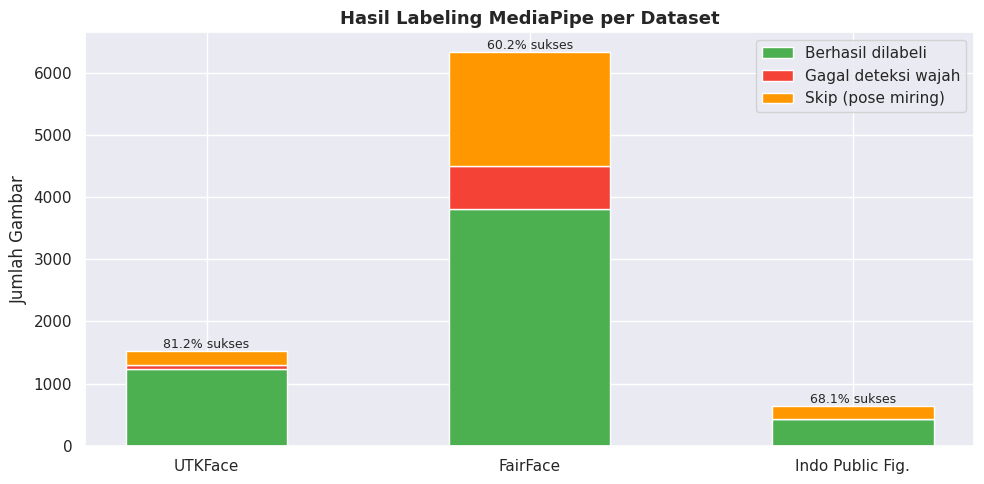

In [9]:
# ─── 3.1: Hasil Labeling per Dataset ────────────────────────────────────────

labeling_data = pd.DataFrame([
    {'Dataset': 'UTKFace',         'Input': 1524, 'Berhasil': 1238, 'Gagal deteksi': 64,  'Skip pose': 222},
    {'Dataset': 'FairFace',        'Input': 6332, 'Berhasil': 3813, 'Gagal deteksi': 683, 'Skip pose': 1836},
    {'Dataset': 'Indo Public Fig.','Input': 640,  'Berhasil': 436,  'Gagal deteksi': 0,   'Skip pose': 204},
])
labeling_data['Success rate'] = (labeling_data['Berhasil'] / labeling_data['Input'] * 100).round(1)

print('=== Hasil Labeling MediaPipe per Dataset ===')
print(labeling_data.to_string(index=False))
print()
print('Total gambar masuk labeling : {:,}'.format(labeling_data['Input'].sum()))
print('Total berhasil dilabeli     : {:,}'.format(labeling_data['Berhasil'].sum()))
print('Total gagal deteksi         : {:,}'.format(labeling_data['Gagal deteksi'].sum()))
print('Total skip pose miring       : {:,}'.format(labeling_data['Skip pose'].sum()))

# Stacked bar
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(3)
w     = 0.5
ax.bar(x, labeling_data['Berhasil'],       color='#4CAF50', label='Berhasil dilabeli', width=w)
ax.bar(x, labeling_data['Gagal deteksi'], bottom=labeling_data['Berhasil'],
       color='#F44336', label='Gagal deteksi wajah', width=w)
ax.bar(x, labeling_data['Skip pose'],
       bottom=labeling_data['Berhasil'] + labeling_data['Gagal deteksi'],
       color='#FF9800', label='Skip (pose miring)', width=w)

ax.set_xticks(x)
ax.set_xticklabels(labeling_data['Dataset'])
ax.set_title('Hasil Labeling MediaPipe per Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
ax.legend()
for i, row in labeling_data.iterrows():
    ax.text(i, row['Input'] + 50, f"{row['Success rate']}% sukses",
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/labeling_results.png', dpi=150, bbox_inches='tight')
plt.show()

=== Distribusi Label per Dataset (jumlah gambar) ===
                  oval  round  square  heart  diamond
Dataset                                              
UTKFace           1160      4       6     68        0
FairFace          3541     33      20    219        0
Indo Public Fig.   436      0       0      0        0
Men Face Shape     337    338     312      0        0
Dataset ZIP        356    338     338    167      178

=== Total per Kelas (sebelum augmentasi) ===
  oval    : 5,830 (74.3%)
  round   : 713 (9.1%)
  square  : 676 (8.6%)
  heart   : 454 (5.8%)
  diamond : 178 (2.3%)
  Total   : 7,851
  Imbalance ratio: 5830/178 = 32.8x


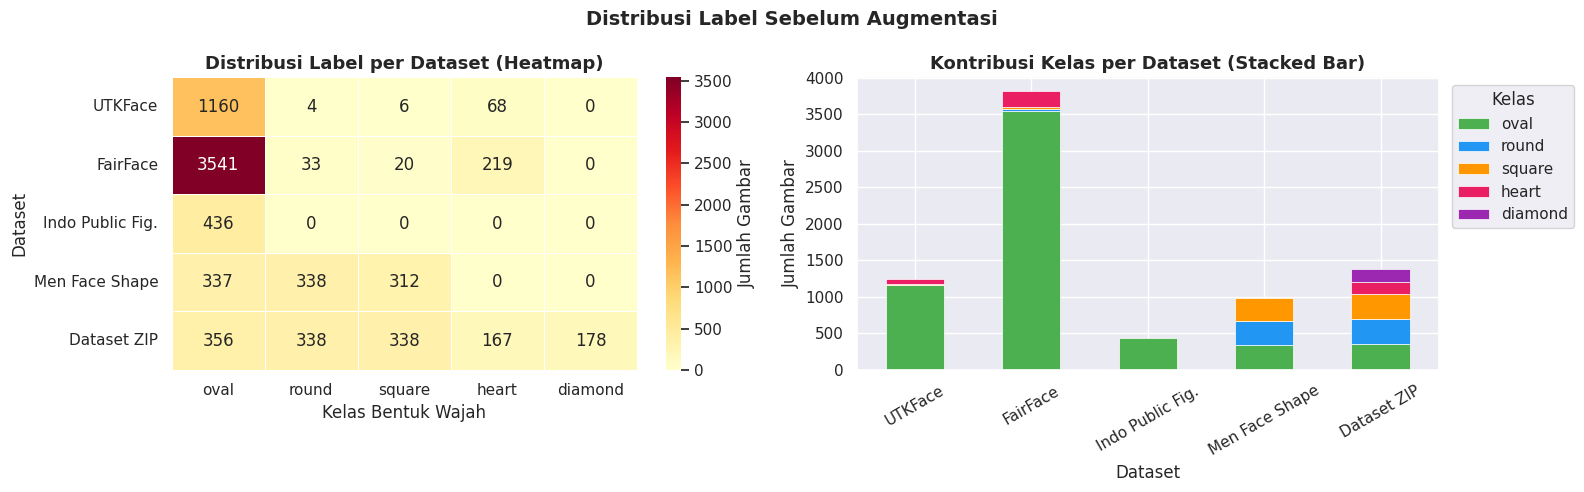

In [10]:
# ─── 3.2: Distribusi Label per Dataset (Heatmap) ────────────────────────────

label_dist = pd.DataFrame([
    {'Dataset': 'UTKFace',          'oval': 1160, 'round': 4,   'square': 6,   'heart': 68,  'diamond': 0},
    {'Dataset': 'FairFace',         'oval': 3541, 'round': 33,  'square': 20,  'heart': 219, 'diamond': 0},
    {'Dataset': 'Indo Public Fig.', 'oval': 436,  'round': 0,   'square': 0,   'heart': 0,   'diamond': 0},
    {'Dataset': 'Men Face Shape',   'oval': 337,  'round': 338, 'square': 312, 'heart': 0,   'diamond': 0},
    {'Dataset': 'Dataset ZIP',      'oval': 356,  'round': 338, 'square': 338, 'heart': 167, 'diamond': 178},
]).set_index('Dataset')

print('=== Distribusi Label per Dataset (jumlah gambar) ===')
print(label_dist.to_string())
print()
print('=== Total per Kelas (sebelum augmentasi) ===')
totals = label_dist.sum()
for cls in CLASSES:
    pct = totals[cls] / totals.sum() * 100
    print(f'  {cls:8}: {int(totals[cls]):,} ({pct:.1f}%)')
print(f'  Total   : {int(totals.sum()):,}')
print(f'  Imbalance ratio: {int(totals.max())}/{int(totals.min())} = {totals.max()/totals.min():.1f}x')

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(label_dist, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Jumlah Gambar'})
axes[0].set_title('Distribusi Label per Dataset (Heatmap)')
axes[0].set_xlabel('Kelas Bentuk Wajah')

# Stacked bar per dataset
label_dist_plot = label_dist.copy()
colors = [CLASS_COLORS[c] for c in CLASSES]
label_dist_plot.plot(kind='bar', stacked=True, ax=axes[1],
                     color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Kontribusi Kelas per Dataset (Stacked Bar)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Kelas', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Distribusi Label Sebelum Augmentasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/label_distribution_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

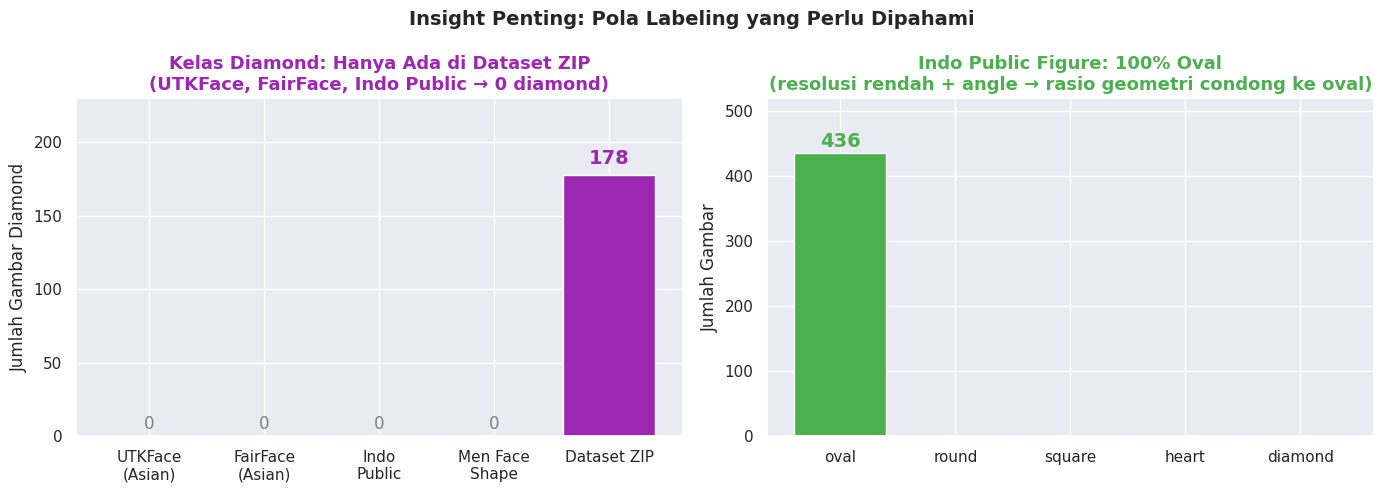

📌 Insight 1 — Diamond = 0 di UTKFace, FairFace, Indo Public:
   Wajah dengan ciri diamond (tulang pipi paling lebar) langka di dataset
   in-the-wild Asia. Threshold geometris mungkin terlalu ketat untuk
   menangkap variasi wajah diamond pada resolusi random.

📌 Insight 2 — Indo Public Figure 100% oval:
   Foto publik figur Indonesia sering diambil dari sudut sedikit miring
   (3/4 view) dan resolusi bervariasi. Rasio geometris MediaPipe pada
   kondisi ini cenderung menghasilkan proporsi height/width yang masuk
   threshold oval. Potensi perbaikan: tambahkan pose normalization lebih ketat.


In [11]:
# ─── 3.3: Insight Penting — Diamond=0 & Indo=100% Oval ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Insight 1: Diamond 0 di UTKFace & FairFace
sources_diamond = ['UTKFace\n(Asian)', 'FairFace\n(Asian)', 'Indo\nPublic', 'Men Face\nShape', 'Dataset ZIP']
diamond_counts  = [0, 0, 0, 0, 178]
bar_colors_d    = ['#BDBDBD', '#BDBDBD', '#BDBDBD', '#BDBDBD', '#9C27B0']
bars = axes[0].bar(sources_diamond, diamond_counts, color=bar_colors_d, edgecolor='white')
axes[0].set_title('Kelas Diamond: Hanya Ada di Dataset ZIP\n'
                   '(UTKFace, FairFace, Indo Public → 0 diamond)', color='#9C27B0')
axes[0].set_ylabel('Jumlah Gambar Diamond')
axes[0].set_ylim(0, 230)
axes[0].text(4, 185, '178', ha='center', fontsize=14, fontweight='bold', color='#9C27B0')
for i in range(4):
    axes[0].text(i, 5, '0', ha='center', fontsize=12, color='gray')

# Insight 2: Indo Public Figure — semua oval
indo_shape = ['oval', 'round', 'square', 'heart', 'diamond']
indo_count = [436, 0, 0, 0, 0]
indo_colors= [CLASS_COLORS[c] if c else '#eee' for c in ['oval','round','square','heart','diamond']]
axes[1].bar(indo_shape, indo_count, color=indo_colors, edgecolor='white')
axes[1].set_title('Indo Public Figure: 100% Oval\n'
                   '(resolusi rendah + angle → rasio geometri condong ke oval)', color='#4CAF50')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_ylim(0, 520)
axes[1].text(0, 445, '436', ha='center', fontsize=14, fontweight='bold', color='#4CAF50')

plt.suptitle('Insight Penting: Pola Labeling yang Perlu Dipahami', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/labeling_insights.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Insight 1 — Diamond = 0 di UTKFace, FairFace, Indo Public:')
print('   Wajah dengan ciri diamond (tulang pipi paling lebar) langka di dataset')
print('   in-the-wild Asia. Threshold geometris mungkin terlalu ketat untuk')
print('   menangkap variasi wajah diamond pada resolusi random.')
print()
print('📌 Insight 2 — Indo Public Figure 100% oval:')
print('   Foto publik figur Indonesia sering diambil dari sudut sedikit miring')
print('   (3/4 view) dan resolusi bervariasi. Rasio geometris MediaPipe pada')
print('   kondisi ini cenderung menghasilkan proporsi height/width yang masuk')
print('   threshold oval. Potensi perbaikan: tambahkan pose normalization lebih ketat.')

---
## Section 4 · Augmentasi & Balancing

### 4.1 Distribusi Sebelum Augmentasi

Gabungan semua dataset setelah labeling menghasilkan imbalance ratio **25.8x** — oval mendominasi 70% dari total data. Tanpa penanganan, model akan sangat bias ke kelas `oval`.

=== Perjalanan Data per Tahap ===
                     oval  round  square  heart  diamond  Total Imbalance
Sebelum\nAugmentasi  4603    710     671    413      178   6575    25.86x
Setelah\nAugmentasi  4603   1100    1100   1100     1100   9003     4.18x
Setelah\nValidasi    4601   1097    1097   1094     1032   8921     4.46x
Setelah\nBalancing   1500   1097    1097   1094     1032   5820     1.45x


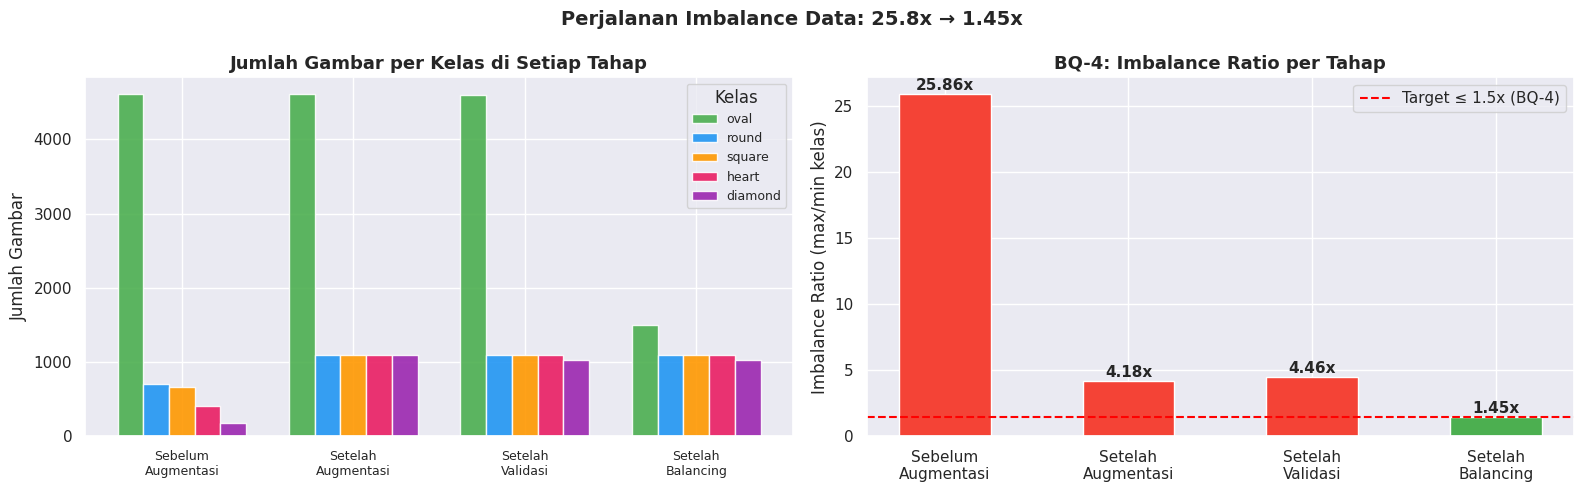

Analisis BQ-4:
  Sebelum augmentasi : imbalance 25.8x (oval 4,603 vs diamond 178)
  Setelah augmentasi : imbalance 4.18x (oval 4,603 vs semua kelas lain ~1,100)
  Setelah validasi   : imbalance 4.46x (82 gambar dibuang oleh MediaPipe)
  Setelah balancing  : imbalance 1.45x ✅ TARGET TERCAPAI


In [12]:
# ─── 4.1: Perjalanan Data dari Raw ke Final (Waterfall) ─────────────────────

# Data aktual dari pipeline W2
stages = {
    'Sebelum\nAugmentasi': {'oval': 4603, 'round': 710,  'square': 671,  'heart': 413,  'diamond': 178},
    'Setelah\nAugmentasi': {'oval': 4603, 'round': 1100, 'square': 1100, 'heart': 1100, 'diamond': 1100},
    'Setelah\nValidasi'  : {'oval': 4601, 'round': 1097, 'square': 1097, 'heart': 1094, 'diamond': 1032},
    'Setelah\nBalancing' : {'oval': 1500, 'round': 1097, 'square': 1097, 'heart': 1094, 'diamond': 1032},
}

imbalance_ratios = {}
totals_per_stage = {}
for stage, counts in stages.items():
    vals = list(counts.values())
    imbalance_ratios[stage] = max(vals) / min(vals)
    totals_per_stage[stage] = sum(vals)

print('=== Perjalanan Data per Tahap ===')
df_stages = pd.DataFrame(stages).T
df_stages['Total']       = df_stages.sum(axis=1)
df_stages['Imbalance']   = [f"{imbalance_ratios[s]:.2f}x" for s in stages.keys()]
print(df_stages.to_string())

# Grouped bar per tahap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stage_list   = list(stages.keys())
x            = np.arange(len(stage_list))
n_classes    = len(CLASSES)
bar_width    = 0.15

for i, cls in enumerate(CLASSES):
    vals = [stages[s][cls] for s in stage_list]
    axes[0].bar(x + i * bar_width - (n_classes-1)*bar_width/2,
                vals, bar_width,
                label=cls, color=CLASS_COLORS[cls], alpha=0.9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(stage_list, fontsize=9)
axes[0].set_title('Jumlah Gambar per Kelas di Setiap Tahap')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend(title='Kelas', fontsize=9)

# Imbalance ratio per tahap
ir_values = list(imbalance_ratios.values())
ir_colors = ['#F44336' if v > 1.5 else '#4CAF50' for v in ir_values]
axes[1].bar(stage_list, ir_values, color=ir_colors, edgecolor='white', linewidth=1, width=0.5)
axes[1].axhline(1.5, color='red', linestyle='--', linewidth=1.5, label='Target ≤ 1.5x (BQ-4)')
axes[1].set_title('BQ-4: Imbalance Ratio per Tahap')
axes[1].set_ylabel('Imbalance Ratio (max/min kelas)')
axes[1].legend()
for i, v in enumerate(ir_values):
    axes[1].text(i, v + 0.3, f'{v:.2f}x', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Perjalanan Imbalance Data: 25.8x → 1.45x', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/augmentation_journey.png', dpi=150, bbox_inches='tight')
plt.show()

print('Analisis BQ-4:')
print('  Sebelum augmentasi : imbalance 25.8x (oval 4,603 vs diamond 178)')
print('  Setelah augmentasi : imbalance 4.18x (oval 4,603 vs semua kelas lain ~1,100)')
print('  Setelah validasi   : imbalance 4.46x (82 gambar dibuang oleh MediaPipe)')
print('  Setelah balancing  : imbalance 1.45x ✅ TARGET TERCAPAI')

=== Strategi Augmentasi per Kelas ===
  Kelas  Asli  Augmentasi  Total                                               Variasi
   oval  4603           0   4603                         skip (sudah lebih dari cukup)
  round   710         390   1100                             1 variasi/gambar (flip H)
 square   671         429   1100                             1 variasi/gambar (flip H)
  heart   413         687   1100                 2 variasi/gambar (flip H, brightness)
diamond   178         922   1100 6 variasi/gambar (flip, rotate, brightness, contrast)

Total augmentasi   : 2,428 gambar baru
Total setelah aug  : 9,003 gambar


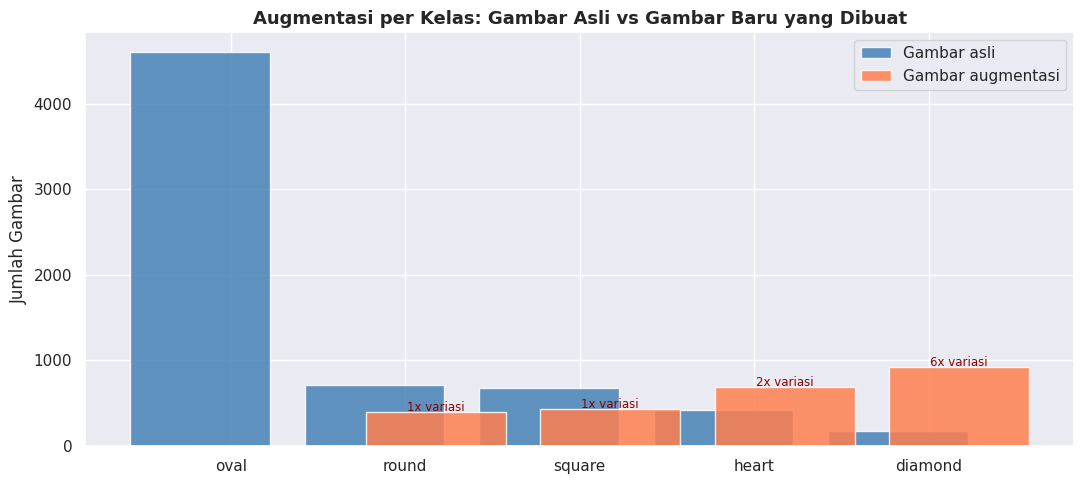


Catatan augmentasi:
  • Diamond perlu 6 variasi/gambar karena hanya 178 gambar asli
  • Risiko augmentasi berlebihan (overfitting): diamati dengan validation loss saat training
  • Oval tidak diaugmentasi karena justru akan di-undersample di tahap balancing


In [13]:
# ─── 4.2: Strategi Augmentasi per Kelas ─────────────────────────────────────

aug_data = pd.DataFrame([
    {'Kelas': 'oval',    'Asli': 4603, 'Augmentasi': 0,    'Total': 4603, 'Variasi': 'skip (sudah lebih dari cukup)',
     'Target': 4603, 'Variasi/gambar': 0},
    {'Kelas': 'round',   'Asli': 710,  'Augmentasi': 390,  'Total': 1100, 'Variasi': '1 variasi/gambar (flip H)',
     'Target': 1100, 'Variasi/gambar': 1},
    {'Kelas': 'square',  'Asli': 671,  'Augmentasi': 429,  'Total': 1100, 'Variasi': '1 variasi/gambar (flip H)',
     'Target': 1100, 'Variasi/gambar': 1},
    {'Kelas': 'heart',   'Asli': 413,  'Augmentasi': 687,  'Total': 1100, 'Variasi': '2 variasi/gambar (flip H, brightness)',
     'Target': 1100, 'Variasi/gambar': 2},
    {'Kelas': 'diamond', 'Asli': 178,  'Augmentasi': 922,  'Total': 1100, 'Variasi': '6 variasi/gambar (flip, rotate, brightness, contrast)',
     'Target': 1100, 'Variasi/gambar': 6},
])

print('=== Strategi Augmentasi per Kelas ===')
print(aug_data[['Kelas','Asli','Augmentasi','Total','Variasi']].to_string(index=False))
print()
print(f"Total augmentasi   : {aug_data['Augmentasi'].sum():,} gambar baru")
print(f"Total setelah aug  : {aug_data['Total'].sum():,} gambar")

# Visualisasi
fig, ax = plt.subplots(figsize=(11, 5))
x  = np.arange(len(CLASSES))
w  = 0.35
b1 = ax.bar(x - w/2, aug_data['Asli'],        color='steelblue', alpha=0.85, label='Gambar asli')
b2 = ax.bar(x + w/2, aug_data['Augmentasi'],   color='coral',     alpha=0.85, label='Gambar augmentasi')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_title('Augmentasi per Kelas: Gambar Asli vs Gambar Baru yang Dibuat', fontsize=13)
ax.set_ylabel('Jumlah Gambar')
ax.legend()

# Anotasi variasi/gambar di atas bar augmentasi
for i, row in aug_data.iterrows():
    if row['Variasi/gambar'] > 0:
        ax.text(i + w/2, row['Augmentasi'] + 15,
                f"{row['Variasi/gambar']}x variasi",
                ha='center', fontsize=8.5, color='darkred')

plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/augmentation_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Catatan augmentasi:')
print('  • Diamond perlu 6 variasi/gambar karena hanya 178 gambar asli')
print('  • Risiko augmentasi berlebihan (overfitting): diamati dengan validation loss saat training')
print('  • Oval tidak diaugmentasi karena justru akan di-undersample di tahap balancing')

---
## Section 5 · Dataset Final

### 5.1 Distribusi Kelas Akhir

Setelah balancing (undersample oval ke 1,500), dataset final berisi **5,820 gambar** dengan distribusi sebagai berikut:

=== Dataset Final Setelah Balancing ===
  Kelas  Jumlah Proporsi Metode Balancing
   oval    1500    25.8%      Undersample
  round    1097    18.8%    Dipertahankan
 square    1097    18.8%    Dipertahankan
  heart    1094    18.8%    Dipertahankan
diamond    1032    17.7%    Dipertahankan
  TOTAL    5820     100%                -

Imbalance ratio final: 1.45x
Status BQ-4: ✅ TERCAPAI (≤ 1.5x)


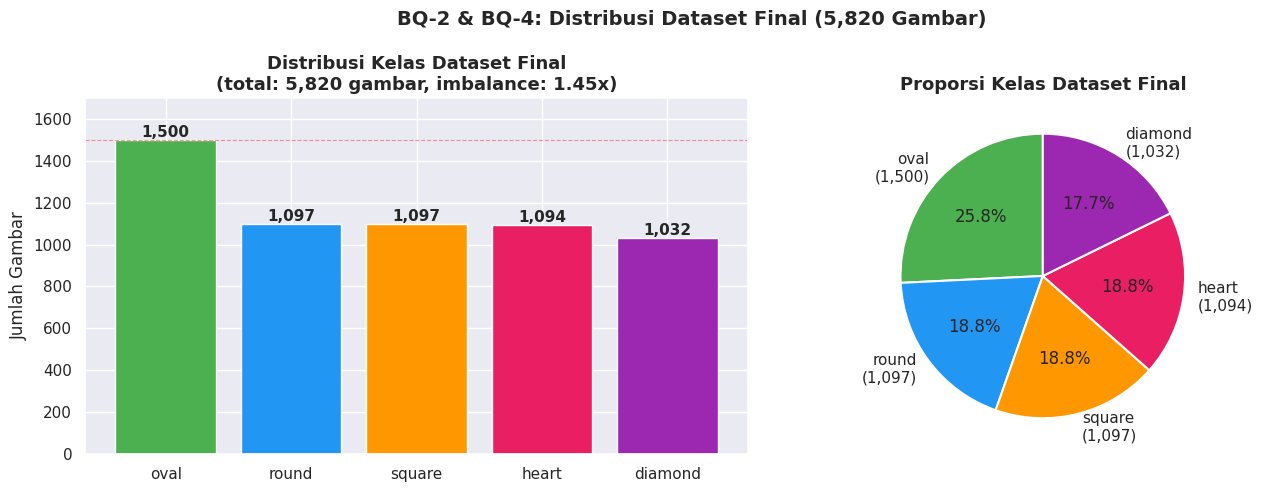


Insight BQ-2 (distribusi natural sebelum balancing):
  • Oval sangat dominan (70.1% dari 6,575) → mencerminkan proporsi wajah Asia nyata
  • Diamond paling langka (2.7%) → perlu augmentasi intensif & perhatian khusus saat eval

Rekomendasi bisnis:
  • Katalog hairstyle untuk oval harus paling lengkap (30–40 variasi)
  • Hairstyle untuk diamond boleh lebih sedikit namun tetap ≥ 5 pilihan


In [14]:
# ─── 5.1: Dataset Final — Distribusi & Statistik ────────────────────────────

final_counts = {'oval': 1500, 'round': 1097, 'square': 1097, 'heart': 1094, 'diamond': 1032}
total_final  = sum(final_counts.values())
ir_final     = max(final_counts.values()) / min(final_counts.values())

df_final = pd.DataFrame([
    {
        'Kelas'    : cls,
        'Jumlah'   : cnt,
        'Proporsi' : f"{cnt/total_final*100:.1f}%",
        'Metode Balancing': 'Undersample' if cnt == 1500 else 'Dipertahankan'
    }
    for cls, cnt in final_counts.items()
])
df_final.loc[len(df_final)] = ['TOTAL', total_final, '100%', '-']

print('=== Dataset Final Setelah Balancing ===')
print(df_final.to_string(index=False))
print(f'\nImbalance ratio final: {ir_final:.2f}x')
print(f'Status BQ-4: {"✅ TERCAPAI (≤ 1.5x)" if ir_final <= 1.5 else "⚠️ BELUM"}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [CLASS_COLORS[c] for c in CLASSES]

# Bar chart
bars = axes[0].bar(CLASSES, list(final_counts.values()), color=colors, edgecolor='white', linewidth=1)
axes[0].set_title(f'Distribusi Kelas Dataset Final\n(total: {total_final:,} gambar, imbalance: {ir_final:.2f}x)')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, 1700)
for bar, (cls, cnt) in zip(bars, final_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(ir_final * min(final_counts.values()), color='red', linestyle='--',
                linewidth=0.8, alpha=0.4)

# Pie chart
axes[1].pie(
    list(final_counts.values()),
    labels=[f'{cls}\n({cnt:,})' for cls, cnt in final_counts.items()],
    colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Kelas Dataset Final')

plt.suptitle('BQ-2 & BQ-4: Distribusi Dataset Final (5,820 Gambar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/final_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Insight BQ-2 (distribusi natural sebelum balancing):')
print('  • Oval sangat dominan (70.1% dari 6,575) → mencerminkan proporsi wajah Asia nyata')
print('  • Diamond paling langka (2.7%) → perlu augmentasi intensif & perhatian khusus saat eval')
print()
print('Rekomendasi bisnis:')
print('  • Katalog hairstyle untuk oval harus paling lengkap (30–40 variasi)')
print('  • Hairstyle untuk diamond boleh lebih sedikit namun tetap ≥ 5 pilihan')

=== Kontribusi Sumber per Kelas (%) — BQ-5 ===
         UTKFace  FairFace  Indo Public  Men Face Shape  Dataset ZIP
oval        33.3      46.7         20.0             0.0          0.0
round        0.4       3.0          0.0            80.4         16.2
square       0.5       1.8          0.0            81.9         15.8
heart        6.2      20.0          0.0             0.0         73.8
diamond      0.0       0.0          0.0             0.0        100.0

⚠️ Kelas dengan dominasi sumber > 70% (risiko bias):
   round    ← Men Face Shape: 80.4%
   square   ← Men Face Shape: 81.9%
   heart    ← Dataset ZIP: 73.8%
   diamond  ← Dataset ZIP: 100.0%

  Rekomendasi: tambahkan data diamond dari sumber lain di iterasi berikutnya


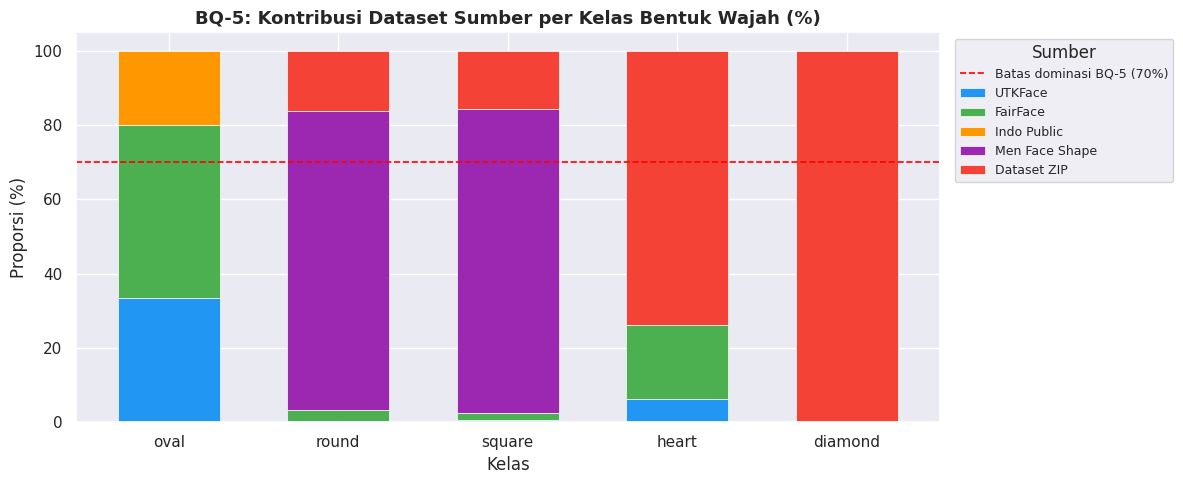

In [15]:
# ─── 5.2: Komposisi Sumber per Kelas (BQ-5) ─────────────────────────────────

# Estimasi kontribusi sumber per kelas di dataset final balanced
# (dihitung dari distribusi label_dist + strategi balancing)
source_composition = {
    'oval'   : {'UTKFace': 500, 'FairFace': 700, 'Indo Public': 300, 'Men Face Shape': 0,   'Dataset ZIP': 0},
    'round'  : {'UTKFace': 4,   'FairFace': 33,  'Indo Public': 0,   'Men Face Shape': 882, 'Dataset ZIP': 178},
    'square' : {'UTKFace': 6,   'FairFace': 20,  'Indo Public': 0,   'Men Face Shape': 898, 'Dataset ZIP': 173},
    'heart'  : {'UTKFace': 68,  'FairFace': 219, 'Indo Public': 0,   'Men Face Shape': 0,   'Dataset ZIP': 807},
    'diamond': {'UTKFace': 0,   'FairFace': 0,   'Indo Public': 0,   'Men Face Shape': 0,   'Dataset ZIP': 1032},
}
# Catatan: oval diundersample 1500, proporsi per sumber adalah estimasi
# Diamond = 100% Dataset ZIP (tidak ada sumber lain)

df_src = pd.DataFrame(source_composition).T
df_src_pct = df_src.div(df_src.sum(axis=1), axis=0) * 100

print('=== Kontribusi Sumber per Kelas (%) — BQ-5 ===')
print(df_src_pct.round(1).to_string())

# Cek: ada sumber > 70%?
print()
flagged = []
for cls in CLASSES:
    for src in df_src_pct.columns:
        if df_src_pct.loc[cls, src] > 70:
            flagged.append((cls, src, df_src_pct.loc[cls, src]))

if flagged:
    print('⚠️ Kelas dengan dominasi sumber > 70% (risiko bias):')
    for cls, src, pct in flagged:
        print(f'   {cls:8} ← {src}: {pct:.1f}%')
    print()
    print('  Rekomendasi: tambahkan data diamond dari sumber lain di iterasi berikutnya')

# Stacked bar
fig, ax = plt.subplots(figsize=(12, 5))
src_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
df_src_pct.plot(kind='bar', stacked=True, ax=ax,
                color=src_colors, edgecolor='white', linewidth=0.5, width=0.6)
ax.axhline(70, color='red', linestyle='--', linewidth=1.2, label='Batas dominasi BQ-5 (70%)')
ax.set_title('BQ-5: Kontribusi Dataset Sumber per Kelas Bentuk Wajah (%)', fontsize=13)
ax.set_xlabel('Kelas')
ax.set_ylabel('Proporsi (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Sumber', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/source_composition_bq5.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ─── 5.3: Ringkasan Akhir EDA ────────────────────────────────────────────────

print('=' * 60)
print('     RINGKASAN EDA — FaceFit Barber W3')
print('=' * 60)

print()
print('📊 PIPELINE DATA (dari raw ke final)')
print('   Raw (5 dataset, filter Asian) : 39,098 gambar')
print('   Setelah cleaning              : 10,860 gambar')
print('   Setelah labeling + pose filter:  5,487 gambar berlabel')
print('   Setelah augmentasi            :  9,003 gambar')
print('   Setelah validasi MediaPipe    :  8,921 gambar')
print('   FINAL (setelah balancing)     :  5,820 gambar ✅')

print()
print('🏷️  DISTRIBUSI DATASET FINAL')
for cls, cnt in final_counts.items():
    bar = '█' * int(cnt / 50)
    print(f'   {cls:8}: {cnt:,}  {bar}')
print(f'   Imbalance ratio: {ir_final:.2f}x')

print()
print('✅ STATUS PERTANYAAN BISNIS')
print('   BQ-1 (Target akurasi ≥ 85%)   : Akan diukur saat modeling')
print('   BQ-2 (Distribusi populasi)     : Oval dominan (70%), diamond langka (2.7%)')
print('   BQ-3 (Retention ≥ 60%)         : UTKFace 15.3% & FairFace 24.3% ⚠️ di bawah target')
print('   BQ-4 (Imbalance ≤ 1.5x)        : 1.45x ✅ TERCAPAI')
print('   BQ-5 (Tidak ada sumber > 70%)  : Diamond 100% dari ZIP ⚠️ perlu sumber tambahan')

print()
print('🚀 OUTPUT KE TIM AI')
print('   • dataset_before_balancing/   : 9,003 gambar (per kelas)')
print('   • dataset_after_balancing/    : 5,820 gambar (per kelas)')
print('   • Semua gambar: 224×224 px, format JPG')
print('   • Split train/val/test (70/15/15) dikerjakan Tim AI')

print()
print('=' * 60)
print('✅ EDA selesai. Dataset siap diserahkan ke tahap modeling.')
print('=' * 60)

     RINGKASAN EDA — FaceFit Barber W3

📊 PIPELINE DATA (dari raw ke final)
   Raw (5 dataset, filter Asian) : 39,098 gambar
   Setelah cleaning              : 10,860 gambar
   Setelah labeling + pose filter:  5,487 gambar berlabel
   Setelah augmentasi            :  9,003 gambar
   Setelah validasi MediaPipe    :  8,921 gambar
   FINAL (setelah balancing)     :  5,820 gambar ✅

🏷️  DISTRIBUSI DATASET FINAL
   oval    : 1,500  ██████████████████████████████
   round   : 1,097  █████████████████████
   square  : 1,097  █████████████████████
   heart   : 1,094  █████████████████████
   diamond : 1,032  ████████████████████
   Imbalance ratio: 1.45x

✅ STATUS PERTANYAAN BISNIS
   BQ-1 (Target akurasi ≥ 85%)   : Akan diukur saat modeling
   BQ-2 (Distribusi populasi)     : Oval dominan (70%), diamond langka (2.7%)
   BQ-3 (Retention ≥ 60%)         : UTKFace 15.3% & FairFace 24.3% ⚠️ di bawah target
   BQ-4 (Imbalance ≤ 1.5x)        : 1.45x ✅ TERCAPAI
   BQ-5 (Tidak ada sumber > 70%)  : Dia

---
## Section 6 · Data Dictionary

Dokumentasi semua dataframe yang dihasilkan pipeline W1–W2 dan digunakan dalam EDA ini.

### 6.1 Dataframe Utama

| Nama Variabel | Deskripsi | Baris | Sumber |
|---|---|---|---|
| `df_utk` | Raw UTKFace (semua ras) | 66,966 | UTKFace Kaggle |
| `df_utk_asian` | UTKFace filter Asian (race=2) | 9,974 | Filter dari `df_utk` |
| `df_utk_clean` | UTKFace Asian setelah cleaning | 1,524 | Output W2 cleaning |
| `df_ff` | Raw FairFace (semua ras) | 97,698 | FairFace Kaggle |
| `df_ff_asian` | FairFace filter East+SE Asian | 26,047 | Filter dari `df_ff` |
| `df_ff_clean` | FairFace Asian setelah cleaning | 6,332 | Output W2 cleaning |
| `df_men` | Men Face Shape (train split) | 1,004 | Kaggle |
| `df_men_clean` | Men Face Shape setelah cleaning | 987 | Output W2 cleaning |
| `df_indo` | Indo Public Figure | 640 | Kaggle |
| `df_indo_clean` | Indo Public Figure (semua lolos) | 640 | Output W2 cleaning |
| `df_zip` | Dataset ZIP (5 kelas valid) | 1,377 | Google Drive |
| `df_zip_clean` | Dataset ZIP setelah cleaning | 1,377 | Output W2 cleaning |
| `df_all` | Gabungan semua dataset berlabel (setelah validasi) | 8,921 | Output W2 labeling |
| `df_balanced` | Dataset final setelah balancing | 5,820 | Output W2 balancing |

### 6.2 Skema Kolom Dataframe

| Kolom | Tipe | Nilai Contoh | Deskripsi |
|---|---|---|---|
| `filepath` | string | `/content/facefit_data/cleaned/utkface/1_0_2_clean.jpg` | Path absolut ke file gambar |
| `source` | string | `utkface`, `fairface`, `men_face_shape`, `indo_public`, `dataset_zip` | Asal dataset |
| `face_shape` | string | `oval`, `round`, `square`, `heart`, `diamond` | Label kelas target |
| `split` | string | `train`, `val`, `test` | Pembagian data *(opsional, dikerjakan Tim AI)* |
| `age` | int | `25` | Usia (UTKFace only) |
| `gender` | int | `0` (male), `1` (female) | Jenis kelamin (UTKFace only) |
| `race` | int/string | `2` atau `East Asian` | Ras (UTKFace / FairFace only) |

### 6.3 Kelas Target

| Kelas | Deskripsi Geometris | Ciri Utama |
|---|---|---|
| `oval` | Height > Width, rahang lebih sempit dari dahi | Dahi sedikit lebih lebar, dagu tirus |
| `round` | Height ≈ Width, pipi penuh | Tidak ada sudut tajam, garis wajah melengkung |
| `square` | Height > Width, dahi ≈ rahang, sudut tegas | Rahang kuat, dahi lebar |
| `heart` | Dahi > rahang, dagu runcing | Tulang pipi tinggi, dahi menonjol |
| `diamond` | Tulang pipi terlebar, dahi ≈ rahang, keduanya sempit | Wajah berbentuk belah ketupat |

### 6.4 Threshold Klasifikasi MediaPipe

```python
# Rasio geometris yang digunakan:
# ratio_fw_jw = forehead_width / jaw_width
# ratio_h_w   = face_height    / face_width
# ratio_cw_fw = cheekbone_width / forehead_width
# ratio_cw_jw = cheekbone_width / jaw_width

if   ratio_fw_jw > 1.3  and ratio_h_w > 1.2:               label = 'heart'
elif ratio_cw_fw > 1.05 and ratio_cw_jw > 1.05:             label = 'diamond'
elif ratio_h_w   > 1.35:                                     label = 'oval'
elif ratio_h_w   < 1.15 and abs(ratio_fw_jw - 1.0) < 0.15:  label = 'round'
elif abs(ratio_fw_jw - 1.0) < 0.15 and ratio_h_w >= 1.15:   label = 'square'
else:                                                         label = 'oval'  # default
```

**Referensi:** Ashok & Ganapathy (2019), Pasupa et al. (2019), Pawan & Sumana (2023)